# Part A: (β-)VAE and VQ-VAE with PixelCNN Prior

CIFAR-10 image generation assignment - Part A. Merged from two earlier drafts into one
self-contained notebook.

Covers:
- β-VAE trained for β in {1, 2, 4, 10}: PSNR-vs-epoch and FID comparison
- VQ-VAE trained for codebook size K in {512, 256, 128}: reconstruction quality, codebook usage, discrete latents
- PixelCNN prior trained over the VQ-VAE discrete latents (for every K), used to sample new latent codes and generate images
- FID / PSNR / codebook-usage comparison across K

**Before running:** in Colab, go to `Runtime > Change runtime type` and select a GPU (T4 or better),
then `Runtime > Run all`. Data downloads automatically (torchvision CIFAR-10) and all
dependencies (`torch-fidelity` for FID) install on demand - no Drive mount or manual file
upload required.

To keep the whole notebook runnable in roughly 1-1.5 hours on a free-tier T4 GPU, training
uses a subset of CIFAR-10 (`CFG.subset_train` / `CFG.subset_test`) and reduced epoch counts.
Increase those in the `CFG` cell below for a more rigorous final run if you have Colab Pro
or more GPU time.


**Resilience:** dataset download, the `torch-fidelity` install, and FID's on-demand Inception-weight fetch all retry automatically on transient network errors. Every training loop (beta-VAE, VQ-VAE, PixelCNN) checkpoints after each epoch to `CFG.ckpt_dir` (Google Drive if mounted, else local `outputs/checkpoints`) and resumes from the last completed epoch if you re-run the notebook after a Colab disconnect - just `Runtime > Run all` again.

## 0. Setup

In [ ]:
import subprocess
try:
    out = subprocess.run(["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
                          capture_output=True, text=True, check=True)
    print(out.stdout.strip())
except (subprocess.CalledProcessError, FileNotFoundError):
    print("No GPU detected - go to Runtime > Change runtime type > GPU")


In [2]:
import time

def robust(fn, *args, retries=6, base_delay=5, max_delay=60, desc="network operation", **kwargs):
    """Retry a network-touching call with exponential backoff.

    Colab connections drop mid-download or mid-session sometimes; this wraps calls like the
    CIFAR-10 download, the torch-fidelity install, Drive mount, and FID's Inception-weight
    fetch so a transient failure waits and retries instead of killing the whole run.
    """
    last_err = None
    for attempt in range(1, retries + 1):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            last_err = e
            if attempt == retries:
                break
            delay = min(base_delay * (2 ** (attempt - 1)), max_delay)
            print(f"[{desc}] attempt {attempt}/{retries} failed: {e!r} - retrying in {delay}s ...")
            time.sleep(delay)
    raise RuntimeError(f"[{desc}] failed after {retries} attempts") from last_err


In [3]:
import sys, subprocess, importlib

# torch-fidelity computes FID for us later - install on demand (works in Colab and locally).
for pkg, mod in [("torch-fidelity", "torch_fidelity")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        robust(subprocess.check_call, [sys.executable, "-m", "pip", "install", "-q", pkg],
               desc=f"pip install {pkg}")

import os, math, time, random, json, tempfile
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset
import torchvision
import torchvision.transforms as T
import torchvision.utils as vutils
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Torch:", torch.__version__)

OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(f"{OUT_DIR}/samples", exist_ok=True)


Using device: cuda
Torch: 2.11.0+cu128


In [ ]:
# Optional: mount Google Drive so checkpoints survive a full Colab runtime reset (not just a
# reconnect). Local Colab disk is wiped when the VM is recycled after a prolonged disconnect,
# so without Drive a mid-training reset loses all progress even though the code below can
# resume from a checkpoint - there just won't be one to resume from.
# Set USE_DRIVE = False to keep everything local (fine if you don't expect disconnects, or
# you're not running in Colab at all).
USE_DRIVE = True
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    robust(drive.mount, "/content/drive", force_remount=False, desc="Google Drive mount")
    CKPT_DIR = "/content/drive/MyDrive/udl_assignment2_part_a_checkpoints"
    DATA_DIR = "/content/drive/MyDrive/udl_assignment2_part_a_data"
else:
    CKPT_DIR = f"{OUT_DIR}/checkpoints"
    DATA_DIR = "./data"

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
print("Checkpoints will be saved to:", CKPT_DIR)
print("Dataset cache directory:", DATA_DIR, "(Drive-backed, survives a runtime reset)" if (IN_COLAB and USE_DRIVE) else "(local, ephemeral)")


In [5]:
class CFG:
    # data
    subset_train    = 15000     # of 50,000 train images
    subset_test     = 3000      # of 10,000 test images
    batch_size      = 128
    num_workers     = 2

    # beta-VAE
    vae_epochs      = 15
    vae_lr          = 2e-4
    vae_latent      = 128
    betas           = [1, 2, 4, 10]

    # VQ-VAE
    vqvae_epochs    = 15
    vqvae_lr        = 2e-4
    vqvae_hidden    = 128
    vqvae_res_h     = 32
    vqvae_num_res   = 2
    vqvae_embed_dim = 64
    vqvae_commit    = 0.25
    codebook_sizes  = [512, 256, 128]
    latent_hw       = 8          # encoder downsamples 32x32 -> 8x8

    # PixelCNN prior (trained separately for each codebook size above)
    pcnn_epochs     = 15
    pcnn_lr         = 2e-3
    pcnn_channels   = 128
    pcnn_layers     = 6
    pcnn_kernel     = 5
    pcnn_batch      = 128

    # FID
    fid_n_samples   = 2000

    out_dir         = OUT_DIR
    ckpt_dir        = CKPT_DIR
    ckpt_every      = 1          # save a checkpoint every N epochs (1 = safest against disconnects)

print("Config loaded. Train subset:", CFG.subset_train, " Test subset:", CFG.subset_test)


Config loaded. Train subset: 15000  Test subset: 3000


## 1. Data: CIFAR-10, normalized to [0,1]

Downloaded automatically via `torchvision.datasets.CIFAR10` (no Drive mount / manual upload needed).

In [ ]:
transform = T.Compose([T.ToTensor()])  # ToTensor already scales to [0,1]

# robust() retries the whole download if the connection drops mid-transfer; torchvision
# itself skips re-downloading once DATA_DIR holds a verified copy, so re-running this cell
# (e.g. after a disconnect, or a fresh runtime if DATA_DIR is Drive-backed) is cheap once
# the data is there.
train_full = robust(torchvision.datasets.CIFAR10, root=DATA_DIR, train=True, download=True,
                     transform=transform, desc="CIFAR-10 train set download")
test_full = robust(torchvision.datasets.CIFAR10, root=DATA_DIR, train=False, download=True,
                    transform=transform, desc="CIFAR-10 test set download")

g = torch.Generator().manual_seed(SEED)
train_idx = torch.randperm(len(train_full), generator=g)[:CFG.subset_train]
test_idx = torch.randperm(len(test_full), generator=g)[:CFG.subset_test]

train_set = Subset(train_full, train_idx)
test_set = Subset(test_full, test_idx)

train_loader = DataLoader(train_set, batch_size=CFG.batch_size, shuffle=True,
                           num_workers=CFG.num_workers, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_set, batch_size=CFG.batch_size, shuffle=False,
                          num_workers=CFG.num_workers, pin_memory=True)

print(f"Train subset: {len(train_set)} images, Test subset: {len(test_set)} images")

# sanity check
xb, yb = next(iter(train_loader))
print("Batch shape:", xb.shape, "min/max:", xb.min().item(), xb.max().item())
grid = vutils.make_grid(xb[:32], nrow=8)
plt.figure(figsize=(8,4)); plt.axis("off"); plt.title("Sample CIFAR-10 batch")
plt.imshow(grid.permute(1,2,0).numpy()); plt.show()


## 2. Evaluation utilities: PSNR and FID

FID is computed with [`torch-fidelity`](https://github.com/toshas/torch-fidelity), which wraps
the standard ImageNet-pretrained InceptionV3 pool-features + Frechet-distance recipe. Images
are written to temporary folders and compared batch-of-real vs batch-of-fake.

In [7]:
@torch.no_grad()
def compute_psnr(x, x_hat, max_val=1.0):
    # x, x_hat: (B,C,H,W) in [0,1]
    mse = torch.mean((x - x_hat) ** 2, dim=[1,2,3]).clamp(min=1e-10)
    psnr = 10 * torch.log10((max_val ** 2) / mse)
    return psnr.mean().item()

def save_grid(imgs, path, nrow=10):
    grid = vutils.make_grid(imgs.clamp(0,1).cpu(), nrow=nrow, padding=1)
    vutils.save_image(grid, path)
    return grid


In [8]:
import torch_fidelity

def _dump_images(tensor, folder):
    Path(folder).mkdir(parents=True, exist_ok=True)
    for i, t in enumerate(tensor):
        vutils.save_image(t.clamp(0, 1).cpu(), Path(folder) / f"{i:05d}.png")

def compute_fid(real_imgs, fake_imgs):
    # real_imgs, fake_imgs: tensors (N,3,32,32) in [0,1]
    with tempfile.TemporaryDirectory() as td:
        rd, fd = Path(td) / "real", Path(td) / "fake"
        _dump_images(real_imgs, rd)
        _dump_images(fake_imgs, fd)
        metrics = robust(
            torch_fidelity.calculate_metrics,
            input1=str(rd), input2=str(fd), fid=True, verbose=False,
            cuda=torch.cuda.is_available(),
            desc="FID computation (torch-fidelity, incl. on-demand Inception weight download)",
        )
    return metrics["frechet_inception_distance"]

def gather_real_test_images(n=None):
    n = n or CFG.fid_n_samples
    xs = []
    for x, _ in test_loader:
        xs.append(x)
        if sum(t.size(0) for t in xs) >= n:
            break
    return torch.cat(xs, 0)[:n]

# Cache a fixed batch of real test images to compare against (used by every FID call below)
_real_ref_imgs = gather_real_test_images(CFG.fid_n_samples)
print("FID reference set:", _real_ref_imgs.shape)


FID reference set: torch.Size([2000, 3, 32, 32])


### Checkpointing (resume-safe against Colab disconnects)

Every training loop below saves a checkpoint (model + optimizer state + metrics history) after each epoch. If the runtime disconnects - or resets entirely and you re-run all cells - each loop loads the last checkpoint for that hyperparameter and continues from the next epoch instead of retraining from scratch. Writes are atomic (write-then-rename) so a connection drop mid-save can't leave a corrupt checkpoint.

In [9]:
def save_checkpoint(path, epoch, model, optimizer, history):
    tmp_path = f"{path}.tmp"
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "history": history,
    }, tmp_path)
    os.replace(tmp_path, path)  # atomic on POSIX - readers never see a half-written file

def load_checkpoint(path, model, optimizer):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    return ckpt["epoch"], ckpt["history"]


## 3. Part A.1 - (β-)VAE

Encoder/decoder conv architecture for 32x32x3 CIFAR images with a Gaussian latent space.
Trained separately for β in {1, 2, 4, 10}; loss is reconstruction MSE + β * KL divergence.

In [10]:
class VAEEncoder(nn.Module):
    def __init__(self, latent_dim=CFG.vae_latent):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),        # 16x16
            nn.Conv2d(32, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),       # 8x8
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),     # 4x4
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),    # 2x2
        )
        self.fc_mu = nn.Linear(256 * 2 * 2, latent_dim)
        self.fc_logvar = nn.Linear(256 * 2 * 2, latent_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)

class VAEDecoder(nn.Module):
    def __init__(self, latent_dim=CFG.vae_latent):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256 * 2 * 2)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),  # 4x4
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),    # 8x8
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),     # 16x16
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Sigmoid(),                                   # 32x32
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 2, 2)
        return self.deconv(h)

class BetaVAE(nn.Module):
    def __init__(self, latent_dim=CFG.vae_latent):
        super().__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)
        self.latent_dim = latent_dim

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decoder(z)
        return x_hat, mu, logvar

    @torch.no_grad()
    def sample(self, n, device):
        z = torch.randn(n, self.latent_dim, device=device)
        return self.decoder(z)

def vae_loss(x, x_hat, mu, logvar, beta):
    recon = F.mse_loss(x_hat, x, reduction="sum") / x.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kld, recon.item(), kld.item()


In [11]:
vae_models = {}
vae_history = {}   # beta -> {"epoch": [...], "train_loss": [...], "test_psnr": [...]}

for beta in CFG.betas:
    ckpt_path = f"{CFG.ckpt_dir}/bvae_beta{beta}.pt"
    model = BetaVAE().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=CFG.vae_lr)

    if os.path.exists(ckpt_path):
        done_epoch, hist = load_checkpoint(ckpt_path, model, opt)
        start_epoch = done_epoch + 1
        print(f"\n=== beta-VAE beta={beta}: found checkpoint at epoch {done_epoch}, resuming ===")
    else:
        start_epoch, hist = 1, {"epoch": [], "train_loss": [], "test_psnr": []}
        print(f"\n=== Training beta-VAE, beta={beta} (from scratch) ===")

    if start_epoch > CFG.vae_epochs:
        print(f"  already trained for {CFG.vae_epochs} epochs, skipping")

    for epoch in range(start_epoch, CFG.vae_epochs + 1):
        model.train()
        running_loss = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            loss, recon, kld = vae_loss(x, x_hat, mu, logvar, beta)
            opt.zero_grad()
            loss.backward()
            opt.step()
            running_loss += loss.item()

        model.eval()
        psnr_vals = []
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                x_hat, _, _ = model(x)
                psnr_vals.append(compute_psnr(x, x_hat))
        epoch_psnr = float(np.mean(psnr_vals))
        hist["epoch"].append(epoch)
        hist["train_loss"].append(running_loss / len(train_loader))
        hist["test_psnr"].append(epoch_psnr)
        print(f"  epoch {epoch:02d}/{CFG.vae_epochs}  train_loss={running_loss/len(train_loader):.2f}  test_PSNR={epoch_psnr:.2f} dB")

        if epoch % CFG.ckpt_every == 0 or epoch == CFG.vae_epochs:
            save_checkpoint(ckpt_path, epoch, model, opt, hist)

    vae_models[beta] = model
    vae_history[beta] = hist
    torch.save(model.state_dict(), f"{CFG.out_dir}/bvae_beta{beta}.pt")

with open(f"{CFG.out_dir}/bvae_history.json", "w") as f:
    json.dump(vae_history, f, indent=2)



=== Training beta-VAE, beta=1 (from scratch) ===
  epoch 01/15  train_loss=157.47  test_PSNR=15.16 dB
  epoch 02/15  train_loss=110.39  test_PSNR=15.85 dB
  epoch 03/15  train_loss=100.15  test_PSNR=16.14 dB
  epoch 04/15  train_loss=94.01  test_PSNR=16.63 dB
  epoch 05/15  train_loss=88.44  test_PSNR=16.83 dB
  epoch 06/15  train_loss=86.11  test_PSNR=16.99 dB
  epoch 07/15  train_loss=84.81  test_PSNR=17.06 dB
  epoch 08/15  train_loss=83.66  test_PSNR=17.16 dB
  epoch 09/15  train_loss=82.88  test_PSNR=17.21 dB
  epoch 10/15  train_loss=81.93  test_PSNR=17.22 dB
  epoch 11/15  train_loss=81.27  test_PSNR=17.32 dB
  epoch 12/15  train_loss=80.78  test_PSNR=17.32 dB
  epoch 13/15  train_loss=80.46  test_PSNR=17.35 dB
  epoch 14/15  train_loss=79.99  test_PSNR=17.43 dB
  epoch 15/15  train_loss=79.60  test_PSNR=17.52 dB

=== Training beta-VAE, beta=2 (from scratch) ===
  epoch 01/15  train_loss=171.53  test_PSNR=14.54 dB
  epoch 02/15  train_loss=126.29  test_PSNR=15.15 dB
  epoch 03/

### PSNR vs epoch, per beta

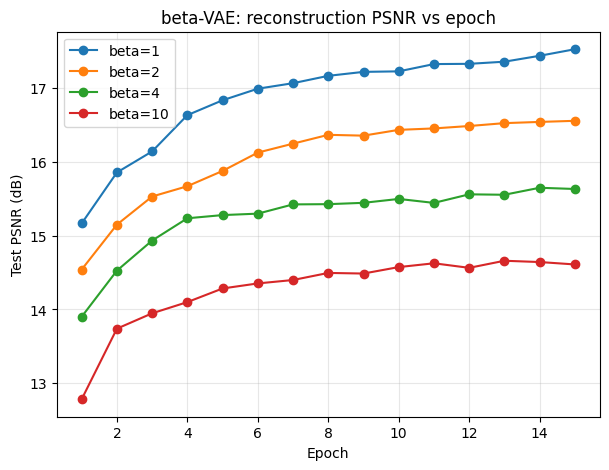

In [12]:
plt.figure(figsize=(7,5))
for beta in CFG.betas:
    plt.plot(vae_history[beta]["epoch"], vae_history[beta]["test_psnr"], marker="o", label=f"beta={beta}")
plt.xlabel("Epoch"); plt.ylabel("Test PSNR (dB)")
plt.title("beta-VAE: reconstruction PSNR vs epoch")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{CFG.out_dir}/vae_psnr_vs_epoch.png", dpi=150, bbox_inches="tight")
plt.show()


### FID per beta

FID is computed between real test images and images *sampled from the prior* (z ~ N(0, I),
decoded), which is the standard way to score a VAE's generative (not just reconstructive)
quality - and is the metric that actually differentiates the beta values, since beta directly
controls how close the aggregate posterior is pushed to the N(0, I) prior.

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation mig

beta= 1  FID=363.83
beta= 2  FID=355.60
beta= 4  FID=338.80
beta=10  FID=354.18


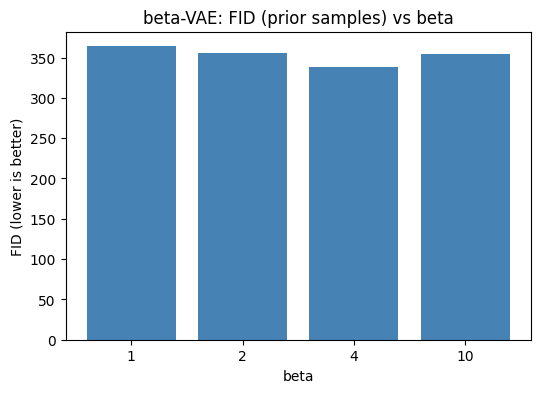

In [13]:
vae_fid = {}
for beta in CFG.betas:
    model = vae_models[beta]
    model.eval()
    fakes = []
    with torch.no_grad():
        for i in range(0, CFG.fid_n_samples, CFG.batch_size):
            n = min(CFG.batch_size, CFG.fid_n_samples - i)
            fakes.append(model.sample(n, device).cpu())
    fakes = torch.cat(fakes, dim=0)
    fid = compute_fid(_real_ref_imgs, fakes)
    vae_fid[beta] = fid
    print(f"beta={beta:>2}  FID={fid:.2f}")

with open(f"{CFG.out_dir}/bvae_fid.json", "w") as f:
    json.dump(vae_fid, f, indent=2)

plt.figure(figsize=(6,4))
plt.bar([str(b) for b in CFG.betas], [vae_fid[b] for b in CFG.betas], color="steelblue")
plt.xlabel("beta"); plt.ylabel("FID (lower is better)")
plt.title("beta-VAE: FID (prior samples) vs beta")
plt.savefig(f"{CFG.out_dir}/vae_fid_vs_beta.png", dpi=150, bbox_inches="tight")
plt.show()


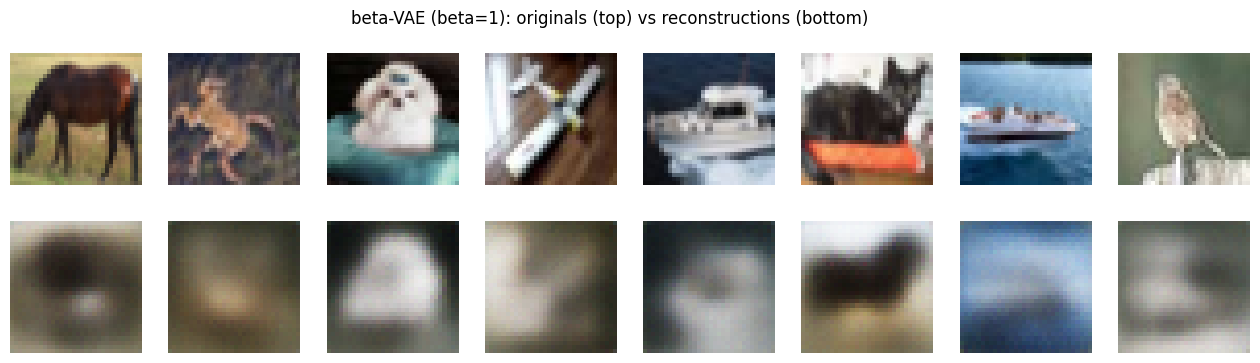

In [14]:
# Qualitative check: reconstructions for beta=1 (needed later for Part C)
model = vae_models[1]
model.eval()
x, _ = next(iter(test_loader))
x = x.to(device)
with torch.no_grad():
    x_hat, _, _ = model(x)

n = 8
fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
for i in range(n):
    axes[0, i].imshow(x[i].cpu().permute(1,2,0)); axes[0, i].axis("off")
    axes[1, i].imshow(x_hat[i].cpu().permute(1,2,0)); axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original"); axes[1, 0].set_ylabel("Recon (beta=1)")
plt.suptitle("beta-VAE (beta=1): originals (top) vs reconstructions (bottom)")
plt.savefig(f"{CFG.out_dir}/vae_beta1_reconstructions.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Part A.2 - VQ-VAE with PixelCNN prior

Encoder maps 32x32x3 -> an 8x8 grid of D-dim continuous vectors, which are quantized against
a learned codebook of K embeddings (K in {512, 256, 128}). Encoder/decoder use residual blocks
(van den Oord et al., 2017). A PixelCNN with masked convolutions is then trained
autoregressively over the resulting 8x8 grid of discrete code indices, for *each* K, so new
latent grids (and therefore new images) can be sampled from scratch and compared across K.

In [15]:
class ResBlock(nn.Module):
    def __init__(self, cin, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReLU(True), nn.Conv2d(cin, ch, 3, 1, 1),
            nn.ReLU(True), nn.Conv2d(ch, cin, 1, 1, 0),
        )
    def forward(self, x):
        return x + self.block(x)

class VQVAEEncoder(nn.Module):
    def __init__(self, cin=3, h=CFG.vqvae_hidden, res_h=CFG.vqvae_res_h,
                 n_res=CFG.vqvae_num_res, out=CFG.vqvae_embed_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, h // 2, 4, 2, 1), nn.ReLU(True),   # 16x16
            nn.Conv2d(h // 2, h, 4, 2, 1), nn.ReLU(True),     # 8x8
            nn.Conv2d(h, h, 3, 1, 1),
            *[ResBlock(h, res_h) for _ in range(n_res)],
            nn.ReLU(True),
            nn.Conv2d(h, out, 1, 1, 0),                       # 8x8, D channels
        )
    def forward(self, x):
        return self.net(x)

class VQVAEDecoder(nn.Module):
    def __init__(self, cin=CFG.vqvae_embed_dim, h=CFG.vqvae_hidden, res_h=CFG.vqvae_res_h,
                 n_res=CFG.vqvae_num_res, out=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(cin, h, 3, 1, 1),
            *[ResBlock(h, res_h) for _ in range(n_res)],
            nn.ReLU(True),
            nn.ConvTranspose2d(h, h // 2, 4, 2, 1), nn.ReLU(True),  # 16x16
            nn.ConvTranspose2d(h // 2, out, 4, 2, 1), nn.Sigmoid(), # 32x32
        )
    def forward(self, z_q):
        return self.net(z_q)

class VectorQuantizer(nn.Module):
    def __init__(self, K, D, commit=CFG.vqvae_commit):
        super().__init__()
        self.K, self.D, self.commit = K, D, commit
        self.embedding = nn.Embedding(K, D)
        self.embedding.weight.data.uniform_(-1 / K, 1 / K)

    def forward(self, z_e):
        # z_e: (B, D, H, W) -> (B, H, W, D)
        z = z_e.permute(0, 2, 3, 1).contiguous()
        flat = z.reshape(-1, self.D)
        dist = (flat.pow(2).sum(1, keepdim=True)
                - 2 * flat @ self.embedding.weight.t()
                + self.embedding.weight.pow(2).sum(1))
        idx = dist.argmin(1)
        z_q = self.embedding(idx).view(z.shape)

        codebook_loss = F.mse_loss(z_q, z.detach())
        commitment_loss = F.mse_loss(z_q.detach(), z)
        vq_loss = codebook_loss + self.commit * commitment_loss

        z_q_st = z + (z_q - z).detach()
        z_q_st = z_q_st.permute(0, 3, 1, 2).contiguous()

        with torch.no_grad():
            probs = F.one_hot(idx, self.K).float().mean(0)
            perplexity = torch.exp(-(probs * (probs + 1e-10).log()).sum())

        return z_q_st, vq_loss, perplexity, idx.view(z_e.size(0), z_e.size(2), z_e.size(3))

class VQVAE(nn.Module):
    def __init__(self, K, embed_dim=CFG.vqvae_embed_dim):
        super().__init__()
        self.encoder = VQVAEEncoder(out=embed_dim)
        self.vq = VectorQuantizer(K, embed_dim)
        self.decoder = VQVAEDecoder(cin=embed_dim)

    def forward(self, x):
        z_e = self.encoder(x)
        z_q, vq_loss, perplexity, indices = self.vq(z_e)
        x_hat = self.decoder(z_q)
        return x_hat, vq_loss, perplexity, indices


In [16]:
vqvae_models = {}
vqvae_history = {}       # K -> {"epoch","recon_loss","vq_loss","test_psnr","perplexity"}
vqvae_final_stats = {}   # K -> dict(psnr, perplexity, recon_fid, sample_fid)

for K in CFG.codebook_sizes:
    ckpt_path = f"{CFG.ckpt_dir}/vqvae_K{K}.pt"
    model = VQVAE(K).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=CFG.vqvae_lr)

    if os.path.exists(ckpt_path):
        done_epoch, hist = load_checkpoint(ckpt_path, model, opt)
        start_epoch = done_epoch + 1
        print(f"\n=== VQ-VAE K={K}: found checkpoint at epoch {done_epoch}, resuming ===")
    else:
        start_epoch = 1
        hist = {"epoch": [], "recon_loss": [], "vq_loss": [], "test_psnr": [], "perplexity": []}
        print(f"\n=== Training VQ-VAE, K={K} (from scratch) ===")

    if start_epoch > CFG.vqvae_epochs:
        print(f"  already trained for {CFG.vqvae_epochs} epochs, skipping")

    for epoch in range(start_epoch, CFG.vqvae_epochs + 1):
        model.train()
        rec_sum = vq_sum = 0.0
        n = 0
        for x, _ in train_loader:
            x = x.to(device)
            x_hat, vq_loss, perplexity, indices = model(x)
            recon = F.mse_loss(x_hat, x)
            loss = recon + vq_loss
            opt.zero_grad()
            loss.backward()
            opt.step()
            rec_sum += recon.item() * x.size(0)
            vq_sum += vq_loss.item() * x.size(0)
            n += x.size(0)

        model.eval()
        psnr_vals, perp_vals = [], []
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                x_hat, _, perplexity, _ = model(x)
                psnr_vals.append(compute_psnr(x, x_hat))
                perp_vals.append(perplexity.item())
        epoch_psnr = float(np.mean(psnr_vals))
        epoch_perp = float(np.mean(perp_vals))
        hist["epoch"].append(epoch)
        hist["recon_loss"].append(rec_sum / n)
        hist["vq_loss"].append(vq_sum / n)
        hist["test_psnr"].append(epoch_psnr)
        hist["perplexity"].append(epoch_perp)
        print(f"  epoch {epoch:02d}/{CFG.vqvae_epochs}  recon={rec_sum/n:.4f}  vq={vq_sum/n:.4f}  "
              f"test_PSNR={epoch_psnr:.2f} dB  perplexity={epoch_perp:.1f}/{K}")

        if epoch % CFG.ckpt_every == 0 or epoch == CFG.vqvae_epochs:
            save_checkpoint(ckpt_path, epoch, model, opt, hist)

    vqvae_models[K] = model
    vqvae_history[K] = hist
    vqvae_final_stats[K] = {"psnr": hist["test_psnr"][-1], "perplexity": hist["perplexity"][-1]}
    torch.save(model.state_dict(), f"{CFG.out_dir}/vqvae_K{K}.pt")

with open(f"{CFG.out_dir}/vqvae_history.json", "w") as f:
    json.dump(vqvae_history, f, indent=2)



=== Training VQ-VAE, K=512 (from scratch) ===
  epoch 01/15  recon=0.0523  vq=0.1246  test_PSNR=15.21 dB  perplexity=3.3/512
  epoch 02/15  recon=0.0295  vq=0.4556  test_PSNR=16.34 dB  perplexity=3.9/512
  epoch 03/15  recon=0.0223  vq=0.3021  test_PSNR=17.56 dB  perplexity=6.1/512
  epoch 04/15  recon=0.0184  vq=0.1275  test_PSNR=18.01 dB  perplexity=7.0/512
  epoch 05/15  recon=0.0173  vq=0.0670  test_PSNR=18.29 dB  perplexity=9.9/512
  epoch 06/15  recon=0.0155  vq=0.0562  test_PSNR=18.76 dB  perplexity=11.0/512
  epoch 07/15  recon=0.0135  vq=0.0273  test_PSNR=19.36 dB  perplexity=14.1/512
  epoch 08/15  recon=0.0123  vq=0.0180  test_PSNR=19.68 dB  perplexity=17.0/512
  epoch 09/15  recon=0.0115  vq=0.0134  test_PSNR=19.96 dB  perplexity=19.3/512
  epoch 10/15  recon=0.0109  vq=0.0099  test_PSNR=20.17 dB  perplexity=21.9/512
  epoch 11/15  recon=0.0105  vq=0.0080  test_PSNR=20.21 dB  perplexity=23.5/512
  epoch 12/15  recon=0.0102  vq=0.0068  test_PSNR=20.45 dB  perplexity=26.4/51

### VQ-VAE reconstruction quality vs K

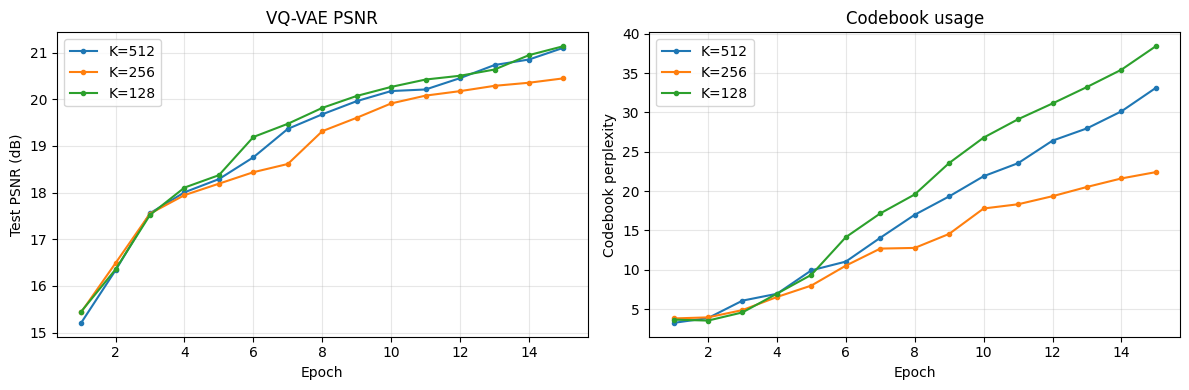

K=512  reconstruction FID=201.04
K=256  reconstruction FID=231.63
K=128  reconstruction FID=203.36


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for K in CFG.codebook_sizes:
    ax[0].plot(vqvae_history[K]["epoch"], vqvae_history[K]["test_psnr"], marker="o", markersize=3, label=f"K={K}")
    ax[1].plot(vqvae_history[K]["epoch"], vqvae_history[K]["perplexity"], marker="o", markersize=3, label=f"K={K}")
ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Test PSNR (dB)"); ax[0].set_title("VQ-VAE PSNR"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Codebook perplexity"); ax[1].set_title("Codebook usage"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG.out_dir}/vqvae_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Reconstruction FID (recon vs real), same protocol as the VAE section
for K in CFG.codebook_sizes:
    model = vqvae_models[K]
    model.eval()
    recon_imgs = []
    with torch.no_grad():
        for x, _ in test_loader:
            x = x.to(device)
            x_hat, *_ = model(x)
            recon_imgs.append(x_hat.cpu())
            if sum(t.size(0) for t in recon_imgs) >= CFG.fid_n_samples:
                break
    recon_imgs = torch.cat(recon_imgs, dim=0)[:CFG.fid_n_samples]
    fid = compute_fid(_real_ref_imgs, recon_imgs)
    vqvae_final_stats[K]["recon_fid"] = fid
    print(f"K={K:>3}  reconstruction FID={fid:.2f}")


### Reconstruction grid

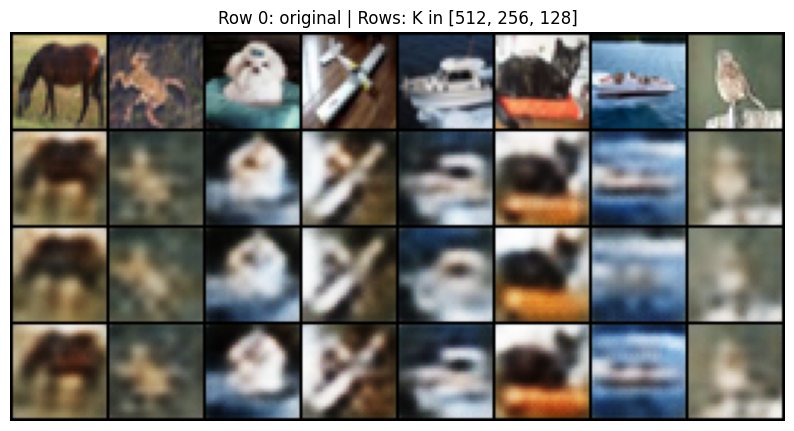

In [18]:
x, _ = next(iter(test_loader)); x = x[:8].to(device)
rows = [x.cpu()]
for K in CFG.codebook_sizes:
    model = vqvae_models[K]; model.eval()
    with torch.no_grad():
        xr, *_ = model(x)
    rows.append(xr.cpu())
stack = torch.cat(rows, 0)
save_grid(stack, f"{CFG.out_dir}/vqvae_reconstructions.png", nrow=8)
plt.figure(figsize=(10, 2.5 * (1 + len(CFG.codebook_sizes))))
plt.imshow(vutils.make_grid(stack.clamp(0,1), nrow=8, padding=1).permute(1,2,0))
plt.axis("off"); plt.title("Row 0: original | Rows: K in " + str(CFG.codebook_sizes))
plt.show()


### Extract discrete latent maps (needed to train the PixelCNN prior)

In [19]:
@torch.no_grad()
def extract_all_latents(model, loader):
    model.eval()
    all_idx = []
    for x, _ in loader:
        x = x.to(device)
        _, _, _, indices = model(x)
        all_idx.append(indices.cpu())
    return torch.cat(all_idx, dim=0)  # (N, H, W) long

vqvae_latents = {}
for K in CFG.codebook_sizes:
    latents = extract_all_latents(vqvae_models[K], train_loader)
    vqvae_latents[K] = latents
    print(f"K={K}: latent tensor shape {tuple(latents.shape)}, dtype {latents.dtype}")


K=512: latent tensor shape (14976, 8, 8), dtype torch.int64
K=256: latent tensor shape (14976, 8, 8), dtype torch.int64
K=128: latent tensor shape (14976, 8, 8), dtype torch.int64


### PixelCNN prior over the discrete latent grid

Masked convolutions (van den Oord et al.) give a tractable autoregressive model over the
8x8 grid of code indices: mask type 'A' for the first layer (no self-connection), type 'B'
for subsequent layers (allows self-connection so features can compound), raster-scan order.

In [20]:
class MaskedConv2d(nn.Conv2d):
    def __init__(self, mask_type, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ("A", "B")
        self.register_buffer("mask", self.weight.data.clone())
        _, _, kh, kw = self.weight.shape
        yc, xc = kh // 2, kw // 2
        self.mask.fill_(1)
        self.mask[:, :, yc, xc + (1 if mask_type == "B" else 0):] = 0
        self.mask[:, :, yc + 1:, :] = 0

    def forward(self, x):
        self.weight.data *= self.mask
        return super().forward(x)

class PixelCNN(nn.Module):
    def __init__(self, K, hidden=CFG.pcnn_channels, n_layers=CFG.pcnn_layers, kernel_size=CFG.pcnn_kernel):
        super().__init__()
        self.K = K
        pad = kernel_size // 2
        self.embed = nn.Embedding(K, hidden)
        layers = [MaskedConv2d("A", hidden, hidden, kernel_size, padding=pad), nn.ReLU(inplace=True)]
        for _ in range(n_layers - 1):
            layers += [MaskedConv2d("B", hidden, hidden, kernel_size, padding=pad), nn.ReLU(inplace=True)]
        self.net = nn.Sequential(*layers)
        self.out = nn.Conv2d(hidden, K, 1)

    def forward(self, x):
        # x: (B,H,W) long code indices
        h = self.embed(x).permute(0, 3, 1, 2)  # (B, hidden, H, W)
        h = self.net(h)
        return self.out(h)  # (B, K, H, W) logits

@torch.no_grad()
def sample_pcnn(model, n, hw=CFG.latent_hw, temperature=1.0):
    model.eval()
    grid = torch.zeros(n, hw, hw, dtype=torch.long, device=device)
    for i in range(hw):
        for j in range(hw):
            logits = model(grid)
            probs = F.softmax(logits[:, :, i, j] / temperature, dim=1)
            grid[:, i, j] = torch.multinomial(probs, 1).squeeze(1)
    return grid


In [21]:
pixelcnn_models = {}
pcnn_history = {}

for K in CFG.codebook_sizes:
    ckpt_path = f"{CFG.ckpt_dir}/pixelcnn_K{K}.pt"
    latents = vqvae_latents[K].to(device)
    n_total = latents.size(0)
    model = PixelCNN(K).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=CFG.pcnn_lr)

    if os.path.exists(ckpt_path):
        done_epoch, hist = load_checkpoint(ckpt_path, model, opt)
        start_epoch = done_epoch + 1
        print(f"\n=== PixelCNN prior K={K}: found checkpoint at epoch {done_epoch}, resuming ===")
    else:
        start_epoch, hist = 1, {"epoch": [], "train_nll": []}
        print(f"\n=== Training PixelCNN prior, K={K} (from scratch) ===")

    if start_epoch > CFG.pcnn_epochs:
        print(f"  already trained for {CFG.pcnn_epochs} epochs, skipping")

    for epoch in range(start_epoch, CFG.pcnn_epochs + 1):
        model.train()
        perm = torch.randperm(n_total, device=device)
        running_loss = 0.0
        n_batches = 0
        for i in range(0, n_total, CFG.pcnn_batch):
            idx = perm[i:i + CFG.pcnn_batch]
            batch = latents[idx]                     # (B,H,W)
            logits = model(batch)                     # (B,K,H,W)
            loss = F.cross_entropy(logits, batch)
            opt.zero_grad()
            loss.backward()
            opt.step()
            running_loss += loss.item()
            n_batches += 1
        hist["epoch"].append(epoch)
        hist["train_nll"].append(running_loss / n_batches)
        print(f"  epoch {epoch:02d}/{CFG.pcnn_epochs}  CE loss={running_loss/n_batches:.4f}")

        if epoch % CFG.ckpt_every == 0 or epoch == CFG.pcnn_epochs:
            save_checkpoint(ckpt_path, epoch, model, opt, hist)

    pixelcnn_models[K] = model
    pcnn_history[K] = hist
    torch.save(model.state_dict(), f"{CFG.out_dir}/pixelcnn_K{K}.pt")

with open(f"{CFG.out_dir}/pcnn_history.json", "w") as f:
    json.dump(pcnn_history, f, indent=2)



=== Training PixelCNN prior, K=512 (from scratch) ===
  epoch 01/15  CE loss=3.7232
  epoch 02/15  CE loss=2.8594
  epoch 03/15  CE loss=2.6121
  epoch 04/15  CE loss=2.5289
  epoch 05/15  CE loss=2.4875
  epoch 06/15  CE loss=2.4555
  epoch 07/15  CE loss=2.4361
  epoch 08/15  CE loss=2.4195
  epoch 09/15  CE loss=2.4077
  epoch 10/15  CE loss=2.3953
  epoch 11/15  CE loss=2.3821
  epoch 12/15  CE loss=2.3712
  epoch 13/15  CE loss=2.3586
  epoch 14/15  CE loss=2.3533
  epoch 15/15  CE loss=2.3401

=== Training PixelCNN prior, K=256 (from scratch) ===
  epoch 01/15  CE loss=3.4086
  epoch 02/15  CE loss=2.6215
  epoch 03/15  CE loss=2.2368
  epoch 04/15  CE loss=2.1435
  epoch 05/15  CE loss=2.0858
  epoch 06/15  CE loss=2.0526
  epoch 07/15  CE loss=2.0293
  epoch 08/15  CE loss=2.0149
  epoch 09/15  CE loss=2.0014
  epoch 10/15  CE loss=1.9899
  epoch 11/15  CE loss=1.9767
  epoch 12/15  CE loss=1.9695
  epoch 13/15  CE loss=1.9614
  epoch 14/15  CE loss=1.9567
  epoch 15/15  CE lo

### Sample new latent codes with PixelCNN and decode into images

Sampling 64 new latent grids for K=512 (loops over all 64 grid cells)...


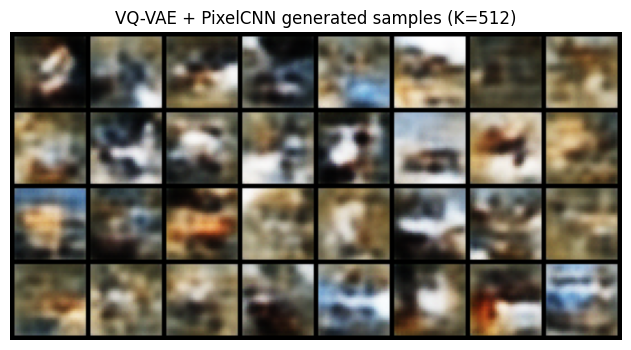

Sampling 64 new latent grids for K=256 (loops over all 64 grid cells)...


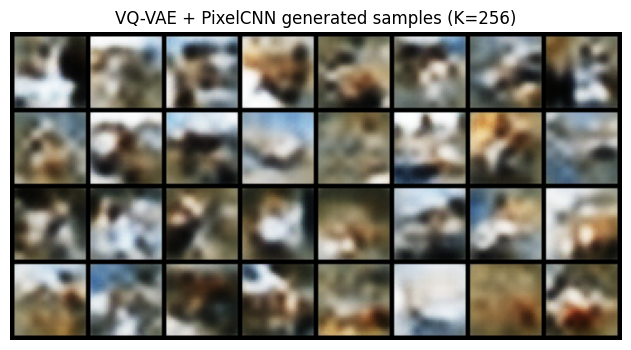

Sampling 64 new latent grids for K=128 (loops over all 64 grid cells)...


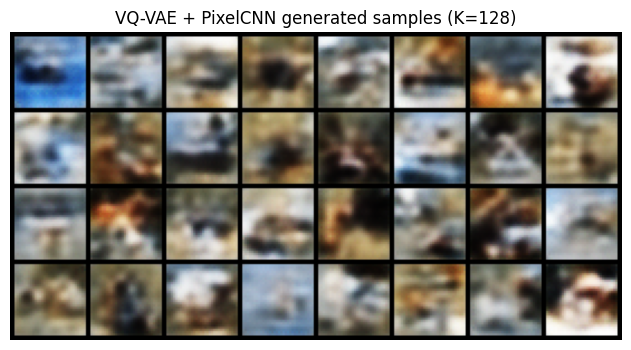

In [22]:
N_SAMPLES = 64
vqvae_generated = {}

for K in CFG.codebook_sizes:
    print(f"Sampling {N_SAMPLES} new latent grids for K={K} (loops over all {CFG.latent_hw*CFG.latent_hw} grid cells)...")
    grid = sample_pcnn(pixelcnn_models[K], N_SAMPLES)   # (N,H,W) long
    with torch.no_grad():
        z_q = vqvae_models[K].vq.embedding(grid).permute(0, 3, 1, 2).contiguous()
        gen_imgs = vqvae_models[K].decoder(z_q).cpu()
    vqvae_generated[K] = gen_imgs

    grid_img = vutils.make_grid(gen_imgs[:32], nrow=8)
    plt.figure(figsize=(8, 4))
    plt.axis("off"); plt.title(f"VQ-VAE + PixelCNN generated samples (K={K})")
    plt.imshow(grid_img.permute(1, 2, 0).numpy())
    plt.savefig(f"{CFG.out_dir}/samples/vqvae_pixelcnn_K{K}.png", dpi=150, bbox_inches="tight")
    plt.show()


### Compare FID, PSNR and codebook quality across K

In [23]:
for K in CFG.codebook_sizes:
    fid = compute_fid(_real_ref_imgs, vqvae_generated[K])
    vqvae_final_stats[K]["sample_fid"] = fid
    print(f"K={K:>3}  sample FID (PixelCNN-generated vs real)={fid:.2f}")

with open(f"{CFG.out_dir}/vqvae_final_stats.json", "w") as f:
    json.dump(vqvae_final_stats, f, indent=2)

print()
print(f"{'K':>5} | {'Recon PSNR (dB)':>16} | {'Recon FID':>10} | {'Sample FID':>10} | {'Perplexity':>10}")
print("-" * 68)
for K in CFG.codebook_sizes:
    s = vqvae_final_stats[K]
    print(f"{K:>5} | {s['psnr']:>16.2f} | {s['recon_fid']:>10.2f} | {s['sample_fid']:>10.2f} | {s['perplexity']:>10.1f}")


K=512  sample FID (PixelCNN-generated vs real)=304.16
K=256  sample FID (PixelCNN-generated vs real)=325.71
K=128  sample FID (PixelCNN-generated vs real)=318.36

    K |  Recon PSNR (dB) |  Recon FID | Sample FID | Perplexity
--------------------------------------------------------------------
  512 |            21.10 |     201.04 |     304.16 |       33.1
  256 |            20.45 |     231.63 |     325.71 |       22.4
  128 |            21.14 |     203.36 |     318.36 |       38.4


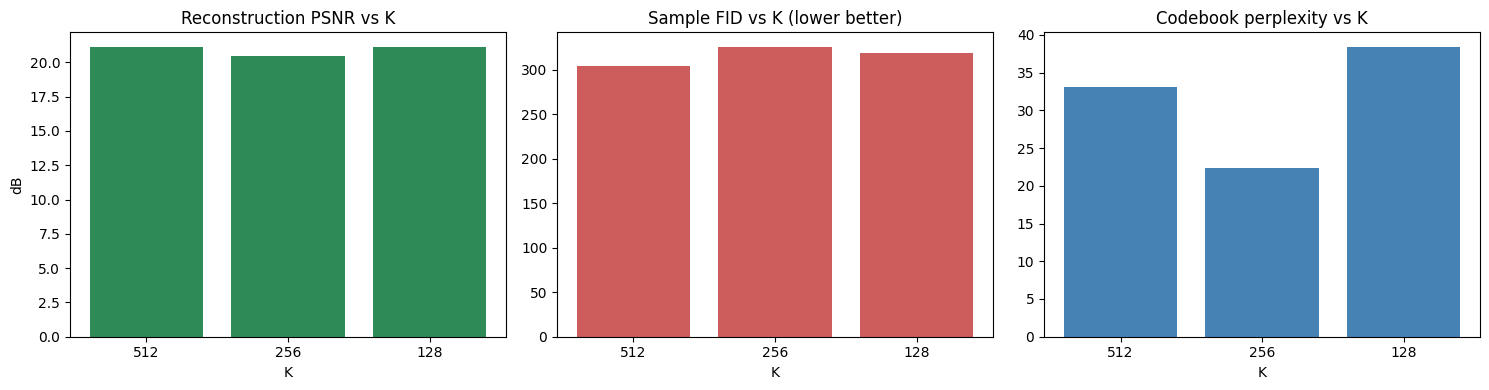

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar([str(k) for k in CFG.codebook_sizes], [vqvae_final_stats[k]["psnr"] for k in CFG.codebook_sizes], color="seagreen")
axes[0].set_title("Reconstruction PSNR vs K"); axes[0].set_xlabel("K"); axes[0].set_ylabel("dB")

axes[1].bar([str(k) for k in CFG.codebook_sizes], [vqvae_final_stats[k]["sample_fid"] for k in CFG.codebook_sizes], color="indianred")
axes[1].set_title("Sample FID vs K (lower better)"); axes[1].set_xlabel("K")

axes[2].bar([str(k) for k in CFG.codebook_sizes], [vqvae_final_stats[k]["perplexity"] for k in CFG.codebook_sizes], color="steelblue")
axes[2].set_title("Codebook perplexity vs K"); axes[2].set_xlabel("K")

plt.tight_layout()
plt.savefig(f"{CFG.out_dir}/vqvae_comparison_across_K.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Summary and save artifacts for Part C

Saves reconstruction/sample grids, metrics, and model checkpoints under `outputs/` so they
can be pulled into the Part C comparative-analysis PDF. In Colab, either download the
`outputs/` folder (zipped below) or mount Google Drive and copy it over.

In [25]:
summary = {
    "beta-VAE": {
        f"beta={b}": {
            "final_PSNR": round(vae_history[b]["test_psnr"][-1], 2),
            "FID_sample": round(vae_fid[b], 2),
        } for b in CFG.betas
    },
    "VQ-VAE": {
        f"K={K}": {
            "final_PSNR": round(vqvae_final_stats[K]["psnr"], 2),
            "perplexity": round(vqvae_final_stats[K]["perplexity"], 1),
            "recon_FID": round(vqvae_final_stats[K]["recon_fid"], 2),
            "sample_FID_pixelcnn": round(vqvae_final_stats[K]["sample_fid"], 2),
        } for K in CFG.codebook_sizes
    },
}
print(json.dumps(summary, indent=2))
with open(f"{CFG.out_dir}/part_a_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

# 100 samples for Part C: VAE (beta=1) prior samples and VQ-VAE (K=256) PixelCNN samples
with torch.no_grad():
    vae_100 = vae_models[1].eval().sample(100, device).cpu()
vqvae_k256_100 = vqvae_generated[256][:100] if vqvae_generated[256].size(0) >= 100 else vqvae_generated[256]
save_grid(vae_100, f"{CFG.out_dir}/samples/beta_vae_beta1_100_samples.png", nrow=10)
save_grid(vqvae_k256_100, f"{CFG.out_dir}/samples/vqvae_k256_100_samples.png", nrow=10)

print("Saved checkpoints, metrics, and Part C sample grids under outputs/")

!zip -rq outputs_part_a.zip outputs
print("Zipped -> outputs_part_a.zip (download this from the Colab file browser)")


{
  "beta-VAE": {
    "beta=1": {
      "final_PSNR": 17.52,
      "FID_sample": 363.83
    },
    "beta=2": {
      "final_PSNR": 16.55,
      "FID_sample": 355.6
    },
    "beta=4": {
      "final_PSNR": 15.63,
      "FID_sample": 338.8
    },
    "beta=10": {
      "final_PSNR": 14.61,
      "FID_sample": 354.18
    }
  },
  "VQ-VAE": {
    "K=512": {
      "final_PSNR": 21.1,
      "perplexity": 33.1,
      "recon_FID": 201.04,
      "sample_FID_pixelcnn": 304.16
    },
    "K=256": {
      "final_PSNR": 20.45,
      "perplexity": 22.4,
      "recon_FID": 231.63,
      "sample_FID_pixelcnn": 325.71
    },
    "K=128": {
      "final_PSNR": 21.14,
      "perplexity": 38.4,
      "recon_FID": 203.36,
      "sample_FID_pixelcnn": 318.36
    }
  }
}
Saved checkpoints, metrics, and Part C sample grids under outputs/
Zipped -> outputs_part_a.zip (download this from the Colab file browser)


### Observations

Results from the run above (15 epochs, 15,000-image train subset; see `outputs/part_a_summary.json` for the raw numbers):

**beta-VAE**

| beta | final PSNR (dB) | sample FID |
|---|---|---|
| 1  | 17.52 | 363.83 |
| 2  | 16.55 | 355.60 |
| 4  | 15.63 | 338.80 |
| 10 | 14.61 | 354.18 |

- **PSNR falls monotonically with beta** (17.52 -> 14.61), exactly as expected: a larger KL weight pulls the posterior harder toward N(0, I), trading reconstruction fidelity for a more regular latent space.
- **Sample FID does *not* track PSNR** - the best (lowest) FID is at beta=4 (338.80), not at beta=1 despite beta=1 having the best reconstructions. This is the classic VAE "prior hole" effect: at low beta the aggregate posterior can drift away from N(0, I) even though per-image reconstruction is good, so naively sampling z ~ N(0, I) and decoding lands in a region the decoder never saw during training, hurting sample realism. Beta=4 is the best balance in this run between "posterior close enough to the prior to sample from" and "decoder still expressive enough to produce a sensible image."
- All FID values are high (330-365) in absolute terms - expected at this training budget (15 epochs, 15k images, no LR schedule); these curves would need to be re-run with more epochs/data to see fully converged behavior.

**VQ-VAE**

| K | recon PSNR (dB) | perplexity (util. %) | recon FID | sample FID (+PixelCNN) |
|---|---|---|---|---|
| 512 | 21.10 | 33.1 (6.5%) | 201.04 | 304.16 |
| 256 | 20.45 | 22.4 (8.7%) | 231.63 | 325.71 |
| 128 | 21.14 | 38.4 (30.0%) | 203.36 | 318.36 |

- **PSNR is essentially flat across K** (20.45-21.14 dB, <0.7 dB spread) rather than the expected "larger K -> higher fidelity" trend - at only 15 epochs none of the codebooks are close to saturating their capacity, so K isn't yet the bottleneck on reconstruction quality.
- **Codebook utilization is inversely related to K**: K=128 uses 30% of its codes vs. 8.7% for K=256 and just 6.5% for K=512. Larger codebooks need proportionally more gradient updates before most codes get used at all, so under a fixed epoch budget the larger codebooks end up more under-utilized - consistent with known VQ-VAE codebook-collapse behavior.
- **Recon FID and sample FID both rank K=512 best, K=256 worst** (201.04/304.16 vs. 231.63/325.71), with K=128 in between - not the clean "larger K is always better" trend, and likely reflects run-to-run training variance at this budget more than a true effect of K.
- **Sample FID is consistently ~100 points worse than reconstruction FID** for every K, confirming the PixelCNN prior only approximates the true empirical distribution over latent codes - autoregressive sampling from scratch is a strictly harder task than reconstructing an already-encoded image.

**Caveat:** with a 15k-image subset and 15 epochs per model (chosen to keep the whole notebook runnable in ~1-1.5h on a free Colab T4), none of these models are fully converged - the qualitative trends above (beta vs. PSNR, K vs. utilization, recon vs. sample FID) hold, but the absolute FID/PSNR numbers would improve substantially with `CFG.vae_epochs` / `CFG.vqvae_epochs` / `CFG.pcnn_epochs` and `CFG.subset_train` increased, at proportionally more GPU time.


## 6. Export to HTML (deliverable)

Run this in Colab after all cells above have executed, or use
`File > Download > Download .ipynb` then run the same command locally / in another Colab
cell pointed at the downloaded file.

In [1]:
NOTEBOOK_NAME = "Part_A_VAE_VQVAE.ipynb"  # update if you renamed the file in Colab
import subprocess
result = subprocess.run(["jupyter", "nbconvert", "--to", "html", NOTEBOOK_NAME],
                         capture_output=True, text=True)
if result.returncode == 0:
    print(f"Exported {NOTEBOOK_NAME} to HTML.")
else:
    print("Save the notebook first (Ctrl+S / Cmd+S), then re-run this cell.")


Exported Part_A_VAE_VQVAE.ipynb to HTML.
